In [1]:
import pickle
import numpy as np
from FastBEMT import BEMT, Environment, Propeller, Simulation

In [2]:
rpm_values = range(3000, 7500, 500)  # 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000
thrust_values_10x5e = []
thrust_values_10x7e = []
thrust_values_10x8e = []

for rpm in rpm_values:
    print(rpm)
    environment = Environment(
        a_inf=343,
        rho=1.225,
        mu=1.81e-5,
        p_ref=2e-5,
    )
    simulation = Simulation(
        revolutions=100,
        timesteps_per_revolution=100,
        device='cuda',
    )

    with open("../Datasets/APC Dicts/10x5E.pkl", "rb") as f:
        blade_dict = pickle.load(f)

    propeller_10x5e = Propeller(
        geometry=blade_dict,
        environment=environment,
        simulation=simulation,
        use_cuda_timing=True,
    )

    with open("../Datasets/APC Dicts/10x7E.pkl", "rb") as f:
        blade_dict = pickle.load(f)

    propeller_10x7e = Propeller(
        geometry=blade_dict,
        environment=environment,
        simulation=simulation,
        use_cuda_timing=True,
    )

    with open("../Datasets/APC Dicts/10x8E.pkl", "rb") as f:
        blade_dict = pickle.load(f)

    propeller_10x8e = Propeller(
        geometry=blade_dict,
        environment=environment,
        simulation=simulation,
        use_cuda_timing=True,
    )
    
    # Run BEMT
    bemt_10x5e = BEMT(propeller=propeller_10x5e, environment=environment, rpm=rpm, v_inf=0)
    thrust_values_10x5e.append(bemt_10x5e.performance_for().thrust_coefficient)

    bemt_10x7e = BEMT(propeller=propeller_10x7e, environment=environment, rpm=rpm, v_inf=0)
    thrust_values_10x7e.append(bemt_10x7e.performance_for().thrust_coefficient)

    bemt_10x8e = BEMT(propeller=propeller_10x8e, environment=environment, rpm=rpm, v_inf=0)
    thrust_values_10x8e.append(bemt_10x8e.performance_for().thrust_coefficient)

3000


C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


3500


C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


4000


...

C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


6500


C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


7000


C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


In [32]:
mean_thrust_10x7e = np.array([1.321277, 1.731331, 2.313578, 2.979274, 3.704298, 4.589624, 5.475130, 6.609976, 7.752219]) / environment.rho / (np.array(rpm_values)/60)**2 / (0.254**4)
std_thrust_10x7e = np.array([0.041742, 0.097682, 0.042499, 0.046986, 0.029013, 0.063586, 0.057441, 0.036956, 0.034880]) / environment.rho / (np.array(rpm_values)/60)**2 / (0.254**4)

In [34]:
rpm = [1975, 2292, 2632, 2908, 3211, 3504, 3815, 4144, 4409, 4711, 5011, 5325, 5624, 5938, 6231, 6542]
ct = [0.0981, 0.1001, 0.1015, 0.1021, 0.1033, 0.1038, 0.1043, 0.1051, 0.1050, 0.1062, 0.1071, 0.1077, 0.1118, 0.1126, 0.1133, 0.1139]
uiuc_10x7e = np.column_stack((rpm, ct))

In [35]:
mean_thrust_10x5e = np.array([1.124, 1.521, 2.004, 2.545, 3.235, 3.885, 4.666, 5.554, 6.484]) / environment.rho / (np.array(rpm_values)/60)**2 / (0.254**4)
std_thrust_10x5e  = np.array([0.050, 0.140, 0.106, 0.085, 0.136, 0.150, 0.129, 0.173, 0.270]) / environment.rho / (np.array(rpm_values)/60)**2 / (0.254**4)

In [36]:
rpm = [2508, 2795, 3093, 3344, 3630, 3919, 4176, 4446, 4743, 5025, 5314, 5596, 5869, 6146, 6434, 6708]
ct = [0.0914, 0.0932, 0.0937, 0.0937, 0.0940, 0.0943, 0.0950, 0.0956, 0.0959, 0.0964, 0.0969, 0.0975, 0.0977, 0.0983, 0.0987, 0.0994]
uiuc_10x5e = np.column_stack((rpm, ct))

In [37]:
mean_thrust_10x8e = np.array([1.306817, 1.709860, 2.296879, 2.953333, 3.709218, 4.509560, 5.523585, 6.568831, 7.734483]) / environment.rho / (np.array(rpm_values)/60)**2 / (0.254**4)
std_thrust_10x8e = np.array([0.002370, 0.005965, 0.006378, 0.008630, 0.011122, 0.009448, 0.017245, 0.022818, 0.016024]) / environment.rho / (np.array(rpm_values)/60)**2 / (0.254**4)

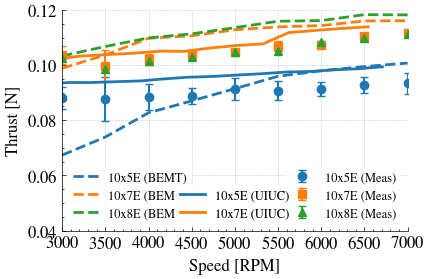

In [59]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science','no-latex'])
plt.figure(figsize=(4.5, 3))

color_5e = 'tab:blue'
color_7e = 'tab:orange'
color_8e = 'tab:green'

# Plotting logic
p1, = plt.plot(list(rpm_values), thrust_values_10x5e, color=color_5e, linestyle='--', linewidth=2, label='10x5E (BEMT)')
e1 = plt.errorbar(list(rpm_values), mean_thrust_10x5e, yerr=std_thrust_10x5e, 
             color=color_5e, fmt='o', elinewidth=1.5, capsize=3, label='10x5E (Meas)', linewidth=2)

p2, = plt.plot(list(rpm_values), thrust_values_10x7e, color=color_7e, linestyle='--', linewidth=2, label='10x7E (BEMT)')
e2 = plt.errorbar(list(rpm_values), mean_thrust_10x7e, yerr=std_thrust_10x7e, 
             color=color_7e, fmt='s', elinewidth=1.5, capsize=3, label='10x7E (Meas)', linewidth=2)

p3, = plt.plot(list(rpm_values), thrust_values_10x8e, color=color_8e, linestyle='--', linewidth=2, label='10x8E (BEMT)')
e3 = plt.errorbar(list(rpm_values), mean_thrust_10x8e, yerr=std_thrust_10x8e, 
             color=color_8e, fmt='^', elinewidth=1.5, capsize=3, label='10x8E (Meas)', linewidth=2)

u1, = plt.plot(uiuc_10x5e[:,0], uiuc_10x5e[:,1], color=color_5e, linestyle='-', linewidth=2, label='10x5E (UIUC)')
u2, = plt.plot(uiuc_10x7e[:,0], uiuc_10x7e[:,1], color=color_7e, linestyle='-', linewidth=2, label='10x7E (UIUC)')
# u3 = plt.plot(uiuc_10x8e[:,0], uiuc_10x8e[:,1], color=color_8e, linestyle='-', linewidth=2, label='10x8E (UIUC)')

# --- SPLIT LEGEND LOGIC ---

# Legend 1: BEMT (Top Left)
# Note: errorbar returns a container, so we use the first element for the legend handle if needed,
# but here we specifically want the line plots (p1, p2, p3).
leg1 = plt.legend([p1, p2, p3], ['10x5E (BEMT)', '10x7E (BEMT)', '10x8E (BEMT)'], 
                  loc='lower left', fontsize=9, frameon=True, edgecolor='none')

# Add the first legend manually so the second one doesn't remove it
plt.gca().add_artist(leg1)

# Legend 2: Measured (Bottom Right)
leg2 = plt.legend([e1, e2, e3], ['10x5E (Meas)', '10x7E (Meas)', '10x8E (Meas)'], 
           loc='lower right', fontsize=9, frameon=True, edgecolor='none')

plt.gca().add_artist(leg2)

leg3 = plt.legend([u1, u2], ['10x5E (UIUC)', '10x7E (UIUC)'], 
           loc='lower center', fontsize=9, frameon=True, edgecolor='none')

plt.gca().add_artist(leg3)

# --- FORMATTING ---
plt.xlabel('Speed [RPM]', fontsize=12)
plt.ylabel('Thrust [N]', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle=':')
plt.xlim(3000, 7000)
plt.ylim(0.04, 0.12)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().tick_params(top=False, right=False, which='both')
plt.tight_layout()
# plt.gca().set_aspect('equal')
plt.savefig('../Figures/BEMT_val.pdf', dpi=200)
plt.show()